In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

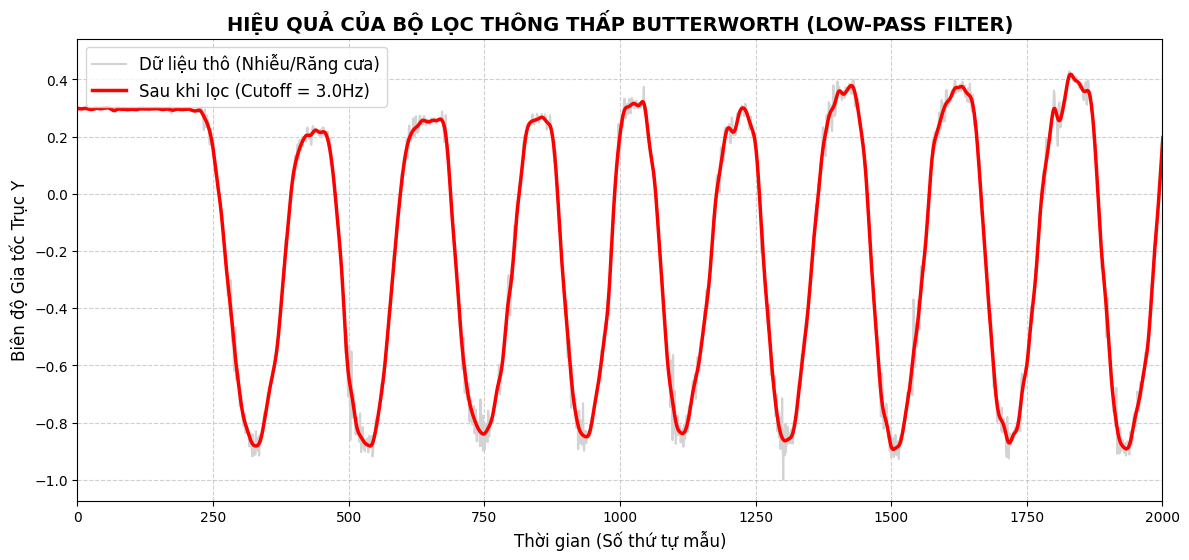

In [30]:
# ==========================================
# 0. Lọc nhiễu data bằng Low-pass-filter
# ==========================================

# Tải dữ liệu thô
df = pd.read_csv('bicep_curl_3.csv')
y_data = df['ay'].values # Lấy trục Y để thử nghiệm
#Hàm lọc -> data đã được lọc
def butter_lowpass_filter(data, cutoff, fs, order=4):
    # Định lý Nyquist: Tần số tối đa hệ thống phân tích được bằng 1/2 Tần số lấy mẫu
    nyq = 0.5 * fs 
    normal_cutoff = cutoff / nyq # Chuẩn hóa tần số cắt
    
    # Lấy các hệ số toán học của bộ lọc (b, a)
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Tuyệt chiêu: Dùng filtfilt thay vì lfilter
    # filtfilt lọc dữ liệu 2 chiều (từ trái qua phải, rồi lộn ngược lại)
    # Giúp loại bỏ hoàn toàn hiện tượng "Trễ pha" (Phase Delay)
    y_filtered = filtfilt(b, a, data)
    
    return y_filtered

#Cấu hình thông số (Các tham số đã chốt từ lý thuyết)
fs = 50.0       # Tần số lấy mẫu: 50 mẫu/giây
cutoff = 3.0    # Tần số cắt: 3 Hz
order = 4       # Bậc 4: Cắt đủ dốc mà không làm méo tín hiệu

#Kích hoạt bộ lọc
y_filtered = butter_lowpass_filter(y_data, cutoff, fs, order)

#Vẽ đồ thị so sánh trực quan
plt.figure(figsize=(14, 6))

# Vẽ dữ liệu thô (Màu xám nhạt để làm nền)
plt.plot(y_data, color='lightgray', linewidth=1.5, label='Dữ liệu thô (Nhiễu/Răng cưa)')

# Vẽ dữ liệu đã lọc (Màu đỏ nổi bật)
plt.plot(y_filtered, color='red', linewidth=2.5, label=f'Sau khi lọc (Cutoff = {cutoff}Hz)')

plt.title('HIỆU QUẢ CỦA BỘ LỌC THÔNG THẤP BUTTERWORTH (LOW-PASS FILTER)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Số thứ tự mẫu)', fontsize=12)
plt.ylabel('Biên độ Gia tốc Trục Y', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Chỉ Zoom vào 300 mẫu đầu tiên (khoảng 6 giây) để nhìn thật rõ sự khác biệt
plt.xlim(0, 2000) 

plt.show()


In [ ]:
# ==========================================
# 1. THUẬT TOÁN MÁY TRẠNG THÁI (STATE MACHINE)
# ==========================================
def state_machine_peak_detector(data, threshold):
    peaks = []
    valleys = []
    
    # Định nghĩa 2 trạng thái
    LOOKING_FOR_VALLEY = 0
    LOOKING_FOR_PEAK = 1
    
    # Khởi tạo trạng thái ban đầu (Giả sử ta đi tìm đáy trước)
    state = LOOKING_FOR_VALLEY 
    
    # Các biến lưu trữ giá trị cực đại/cực tiểu tạm thời
    temp_max = data[0]
    temp_max_pos = 0
    temp_min = data[0]
    temp_min_pos = 0
    
    for i in range(1, len(data)):
        val = data[i]
        
        if state == LOOKING_FOR_VALLEY:
            # Liên tục dò đáy sâu nhất
            if val < temp_min:
                temp_min = val
                temp_min_pos = i
            # Nếu đồ thị vòng lên và vượt quá Ngưỡng chênh lệch -> Chốt Đáy!
            elif val >= temp_min + threshold:
                valleys.append(temp_min_pos)
                state = LOOKING_FOR_PEAK  # Đảo trạng thái
                temp_max = val            # Reset mốc để đi tìm đỉnh mới
                temp_max_pos = i
                
        elif state == LOOKING_FOR_PEAK:
            # Liên tục dò đỉnh cao nhất
            if val > temp_max:
                temp_max = val
                temp_max_pos = i
            # Nếu đồ thị vòng xuống và vượt quá Ngưỡng chênh lệch -> Chốt Đỉnh!
            elif val <= temp_max - threshold:
                peaks.append(temp_max_pos)
                state = LOOKING_FOR_VALLEY # Đảo trạng thái
                temp_min = val             # Reset mốc để đi tìm đáy mới
                temp_min_pos = i
        
    # Sau khi chạy hết dữ liệu, nếu máy đang kẹt ở trạng thái TÌM ĐỈNH
    if state == LOOKING_FOR_PEAK:
        peaks.append(temp_max_pos) # Ép chốt sổ cái đỉnh cuối cùng!
        
    # Ngược lại, nếu người dùng đeo ngược cảm biến và kẹt ở TÌM ĐÁY
    elif state == LOOKING_FOR_VALLEY and len(peaks) > len(valleys):
        valleys.append(temp_min_pos)
    # --------------------------------------------

    return peaks, valleys
    return peaks, valleys

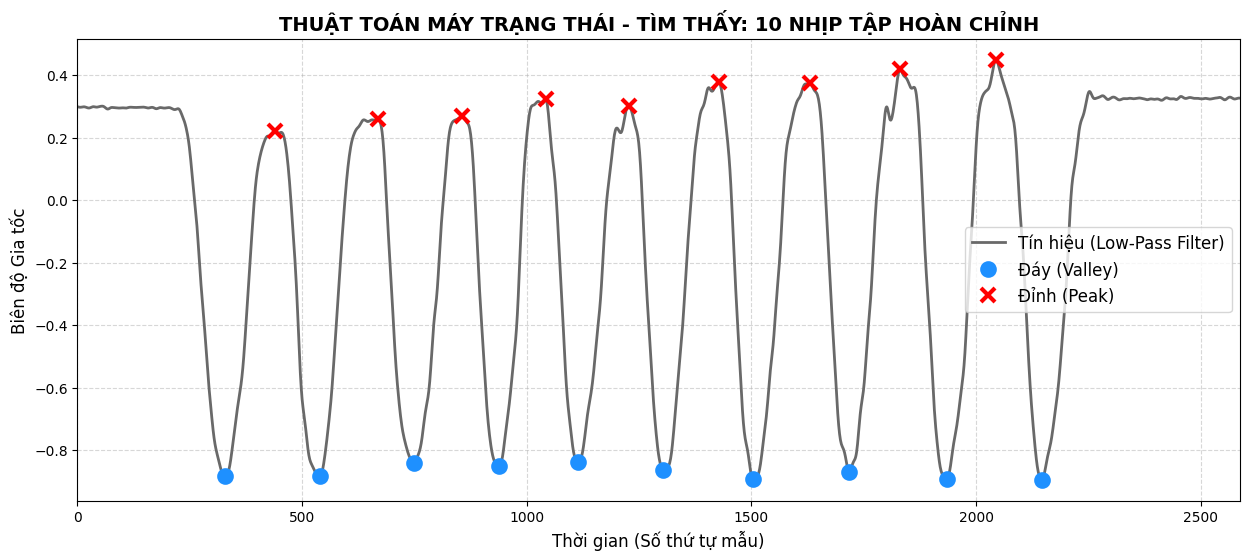

In [ ]:
# ==========================================
# 2. THỰC THI & TÍNH TOÁN
# ==========================================
# Ngưỡng chênh lệch (Hysteresis Threshold): 
# Đồ thị của bạn rơi từ ~0.4 xuống -0.8 (chênh lệch 1.2G). 
# Chọn THRESHOLD = 0.6 là mức an toàn để lọc sạch các rung lắc nhỏ.
THRESHOLD = 0.4

peaks, valleys = state_machine_peak_detector(y_filtered, THRESHOLD)

# Tính số nhịp tập 
rep_count = min(len(peaks), len(valleys))

# ==========================================
# 3. VẼ ĐỒ THỊ KIỂM CHỨNG
# ==========================================
plt.figure(figsize=(15, 6))

# Vẽ đồ thị đã lọc nhiễu
plt.plot(y_filtered, color='dimgray', linewidth=2, label='Tín hiệu (Low-Pass Filter)')

# Đánh dấu Đáy (Valleys) bằng chấm Tròn Xanh
plt.plot(valleys, y_filtered[valleys], "o", color='dodgerblue', markersize=10, markeredgewidth=2, label='Đáy (Valley)')

# Đánh dấu Đỉnh (Peaks) bằng chữ X Đỏ
plt.plot(peaks, y_filtered[peaks], "x", color='red', markersize=10, markeredgewidth=3, label='Đỉnh (Peak)')

plt.title(f'THUẬT TOÁN MÁY TRẠNG THÁI - TÌM THẤY: {rep_count} NHỊP TẬP HOÀN CHỈNH', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Số thứ tự mẫu)', fontsize=12)
plt.ylabel('Biên độ Gia tốc', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(0, len(y_data)) 
plt.show()